/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_4565/3202260202.py:5: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('rebalanced_age_data.csv')
/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_4565/3202260202.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()            # Create a new figure for each histogram


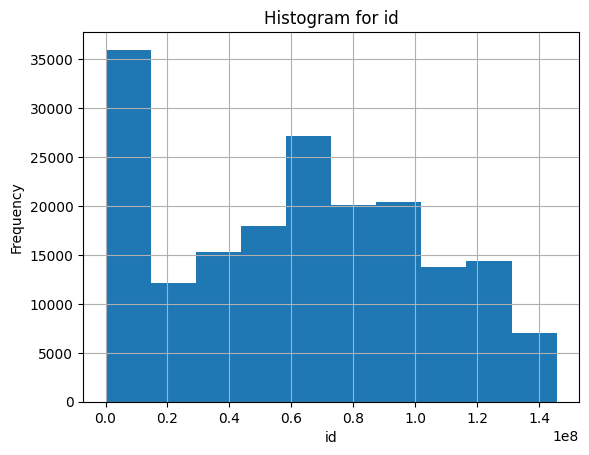

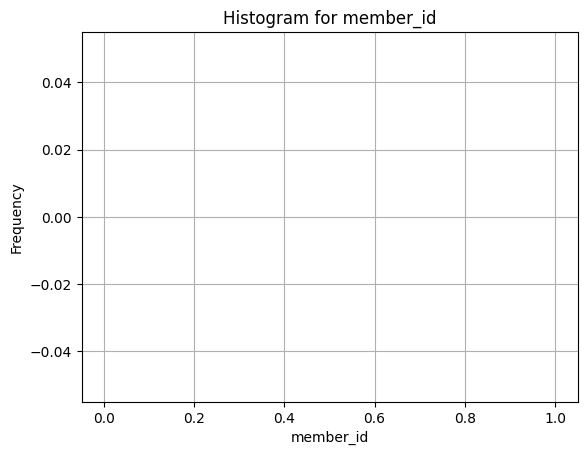

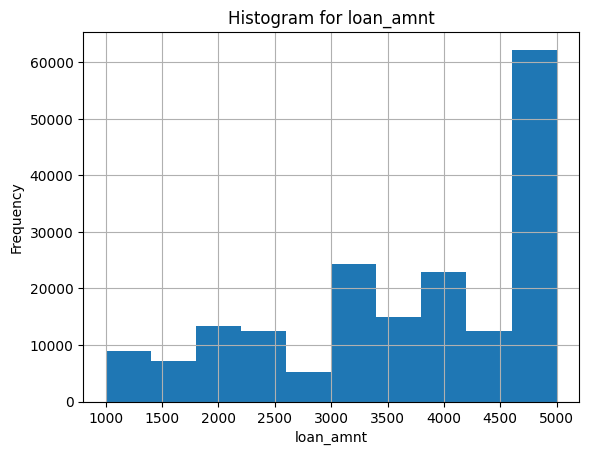

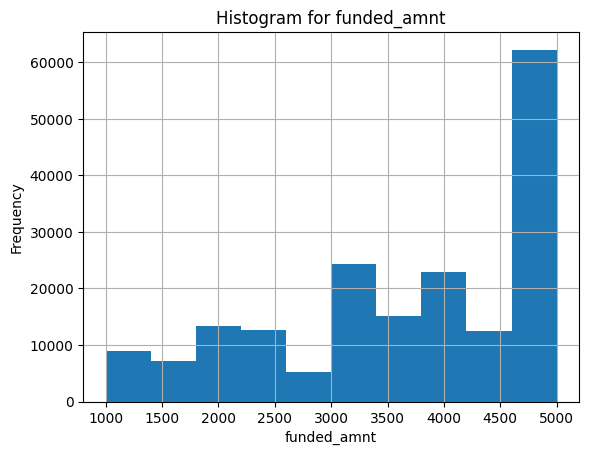

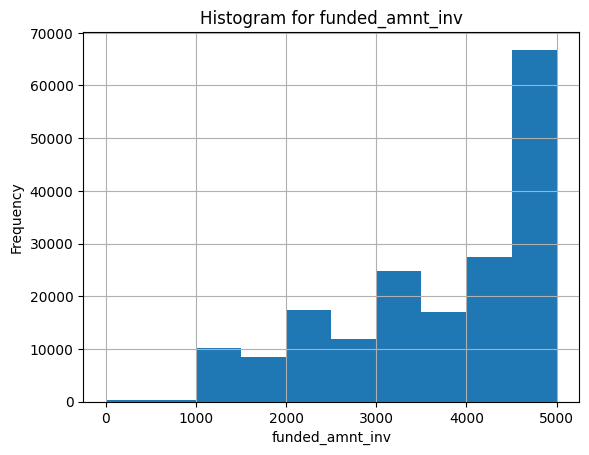

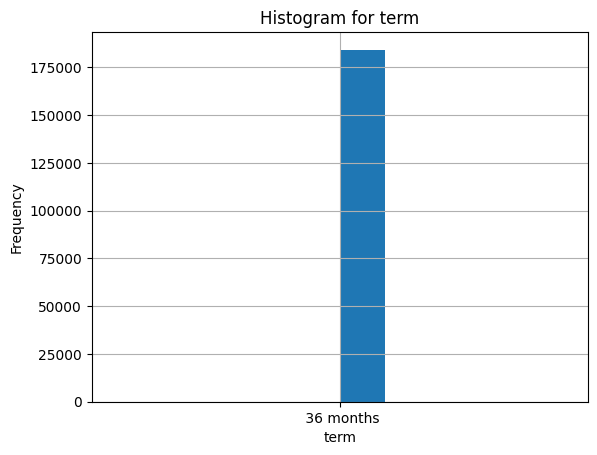

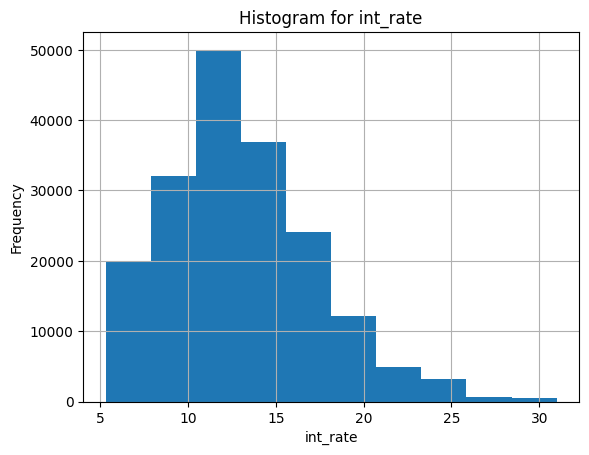

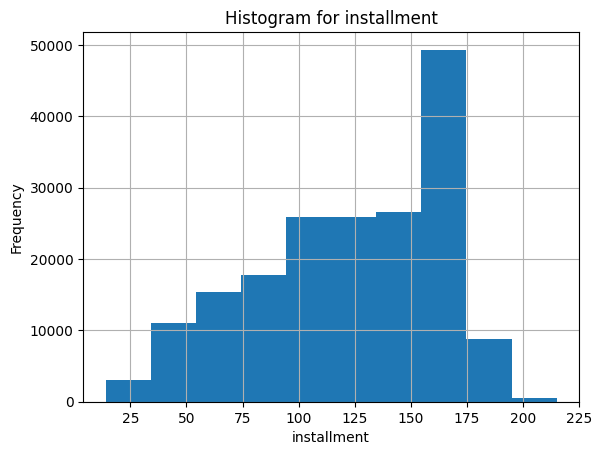

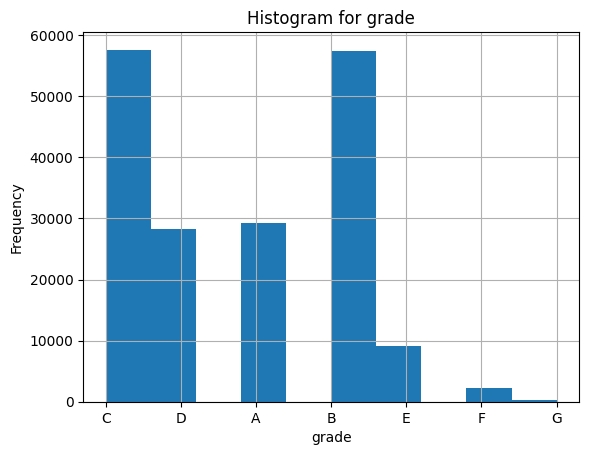

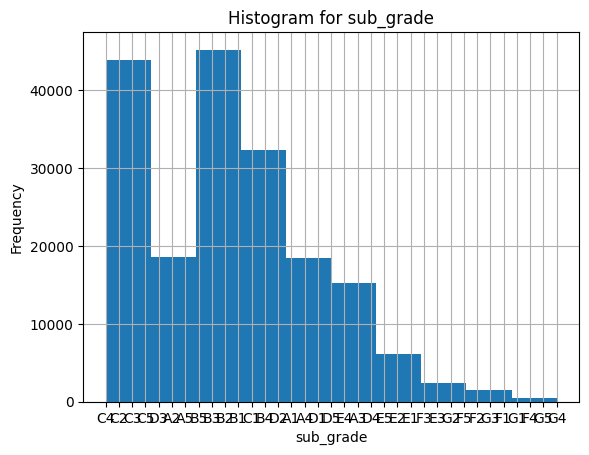

KeyboardInterrupt: 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame (update the path as needed)
df = pd.read_csv('rebalanced_age_data.csv')

# Loop over each column in the DataFrame
for column in df.columns:
    plt.figure()            # Create a new figure for each histogram
    df[column].hist()       # Plot histogram for the column
    plt.title(f'Histogram for {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

# Display all the plots
plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_27396/1170667822.py:1: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('rebalanced_age_data.csv')


<AxesSubplot: >

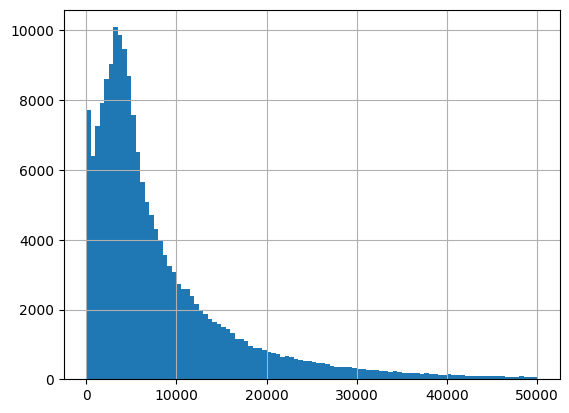

In [5]:
df = pd.read_csv('rebalanced_age_data.csv')
df["revol_bal"].hist(range=(0, 50000), bins=100)

<AxesSubplot: >

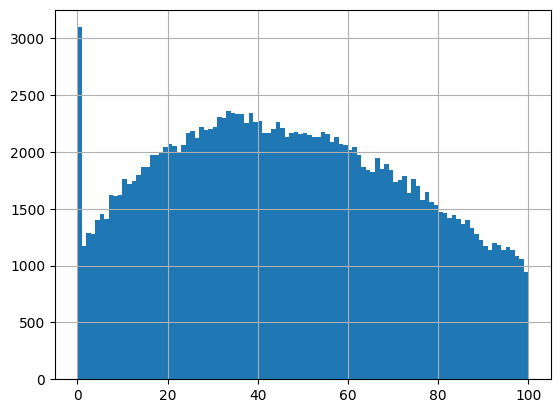

In [7]:
df["revol_util"].hist(range=(0, 100), bins=100)

<AxesSubplot: >

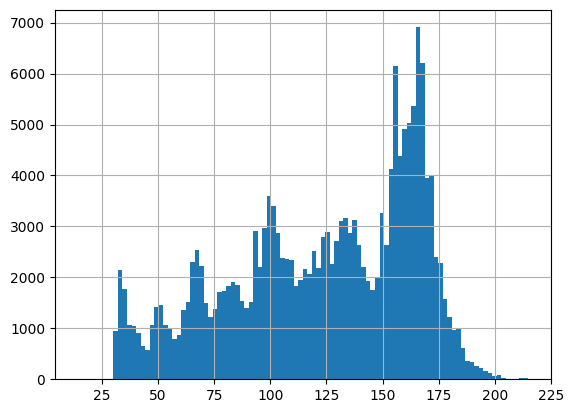

In [9]:
df["installment"].hist(bins=100)

<AxesSubplot: >

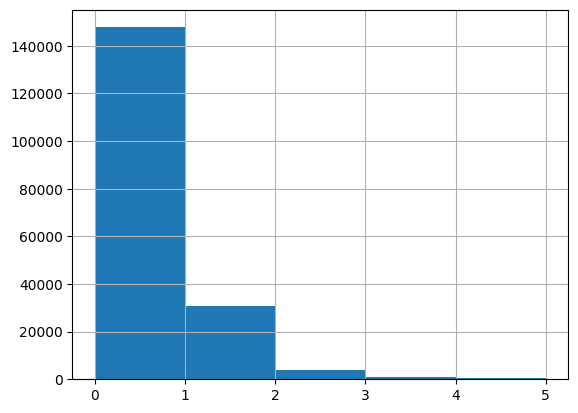

In [13]:
df["pub_rec"].hist(range=(0,5),bins=5)

<AxesSubplot: >

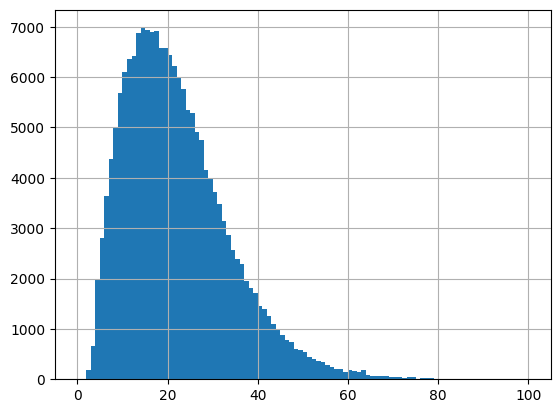

In [15]:
df["total_acc"].hist(range=(0,100),bins=100)

<AxesSubplot: >

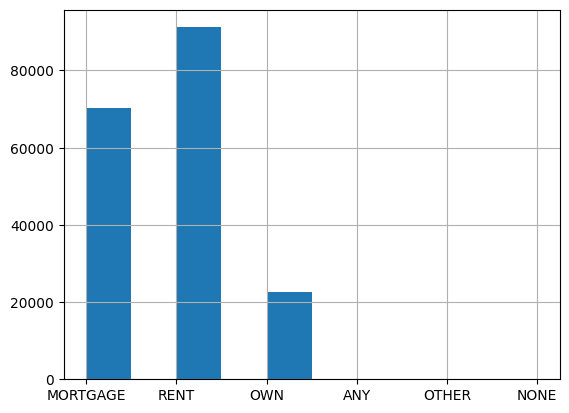

In [17]:
df["home_ownership"].hist()

<AxesSubplot: >

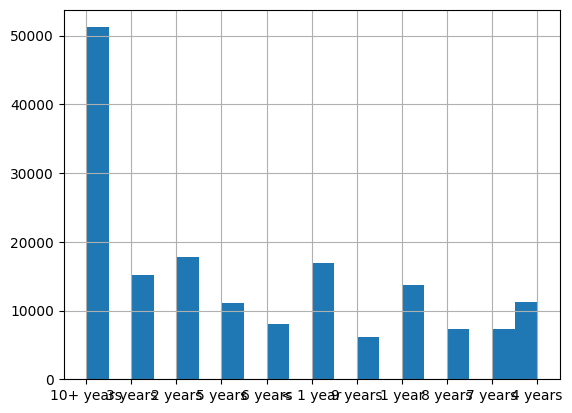

In [20]:
df["emp_length"].hist(bins=20)

<AxesSubplot: >

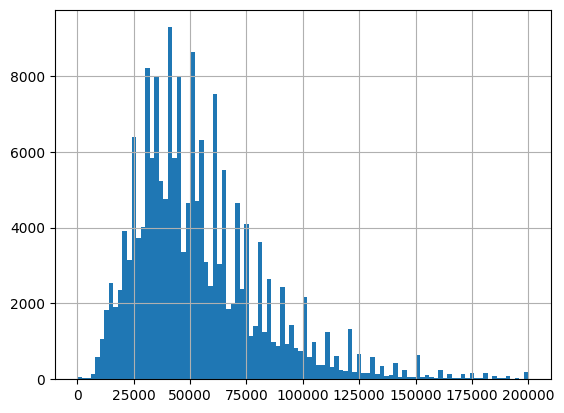

In [22]:
df["annual_inc"].hist(range=(0, 200000), bins=100)

<AxesSubplot: >

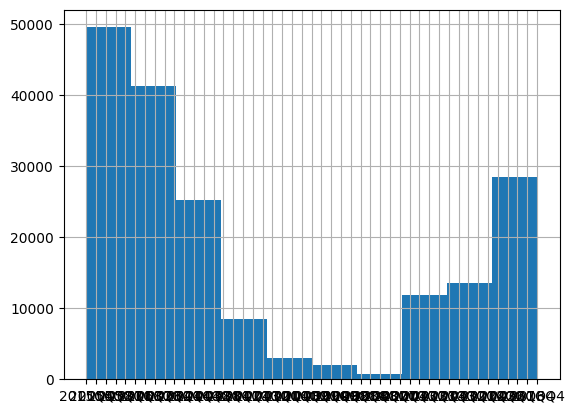

In [23]:
df["issue_quarter"].hist()

<AxesSubplot: >

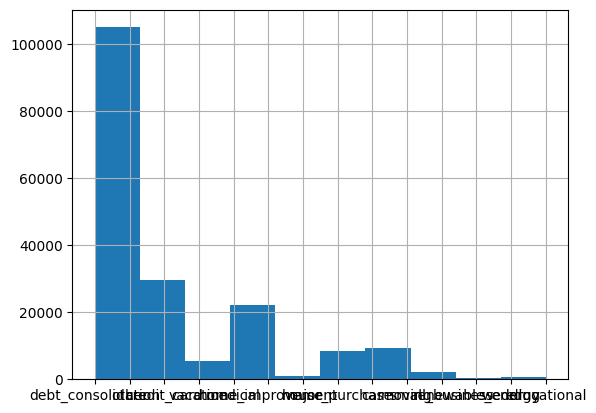

In [24]:
df["purpose"].hist()

<AxesSubplot: >

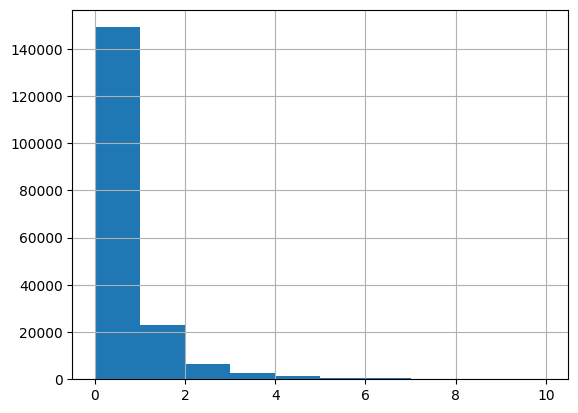

In [27]:
df["delinq_2yrs"].hist(range=(0, 10), bins=10)

<AxesSubplot: >

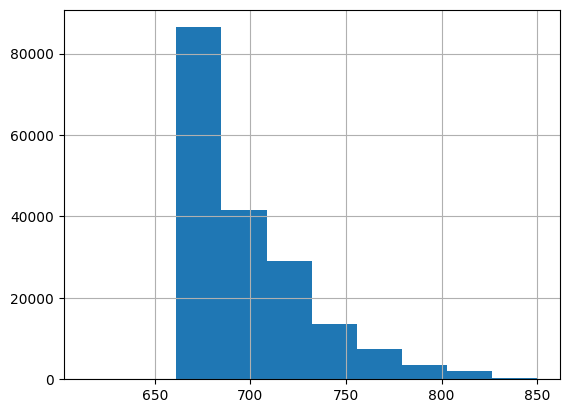

In [ ]:
df["fico_range_high"].hist()

<AxesSubplot: >

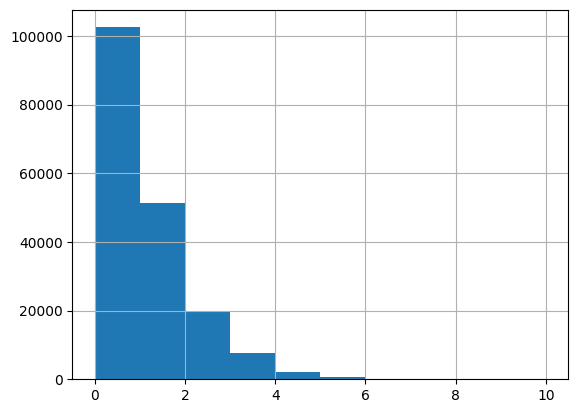

In [30]:
df["inq_last_6mths"].hist(range=(0, 10), bins=10)

<AxesSubplot: >

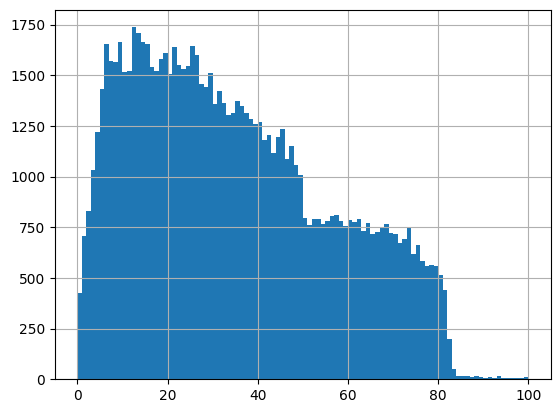

In [33]:
df["mths_since_last_delinq"].hist(range=(0, 100), bins=100)

<AxesSubplot: >

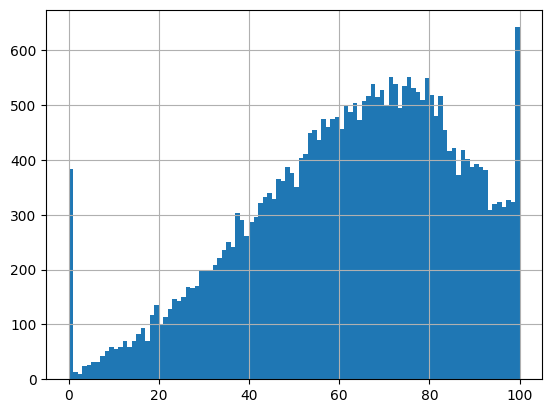

In [34]:
df["mths_since_last_record"].hist(range=(0, 100), bins=100)

<AxesSubplot: >

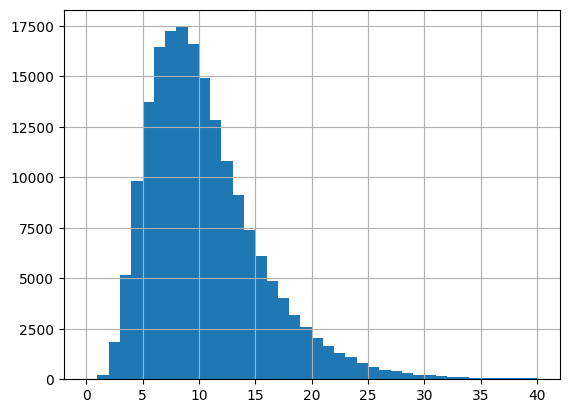

In [36]:
df["open_acc"].hist(range=(0, 40), bins=40)

<AxesSubplot: >

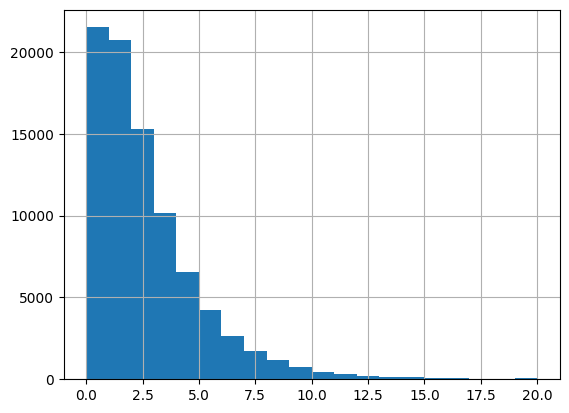

In [38]:
df["inq_last_12m"].hist(range=(0, 20), bins=20)

<AxesSubplot: >

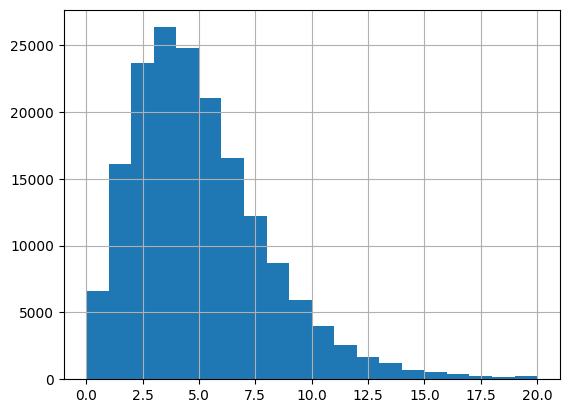

In [39]:
df["acc_open_past_24mths"].hist(range=(0, 20), bins=20)

<AxesSubplot: >

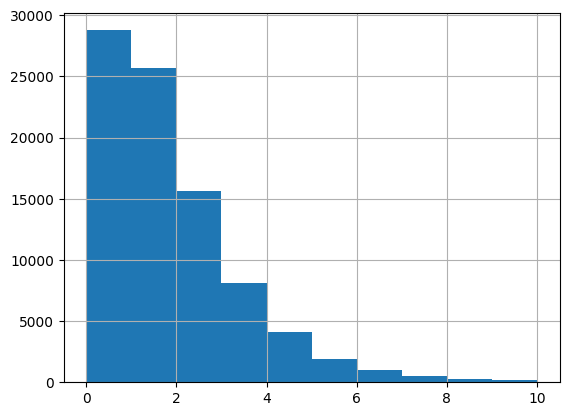

In [41]:
df["open_rv_12m"].hist(range=(0, 10), bins=10)

<AxesSubplot: >

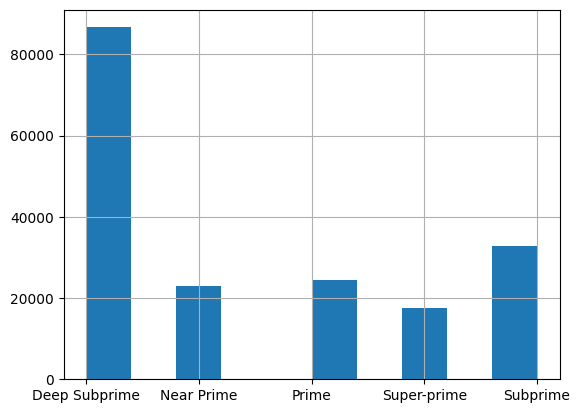

In [42]:
df["fico_bucket_pct"].hist()

<AxesSubplot: >

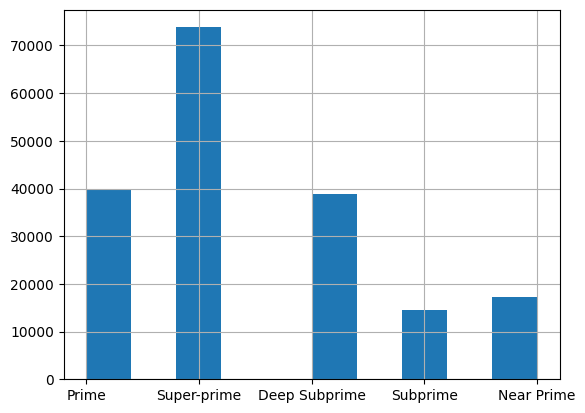

In [43]:
df["fico_bucket_pct_t4"].hist()

<AxesSubplot: >

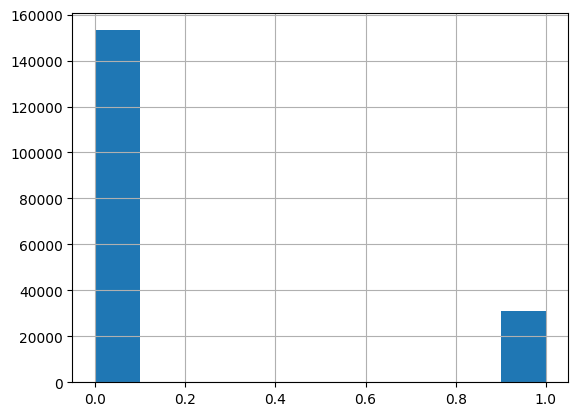

In [44]:
df["default_indicator"].hist()

In [47]:
from distfit import distfit
import pandas as pd
import bnlearn as bn
df = pd.read_csv('rebalanced_age_data.csv')

AttributeError: module 'numpy' has no attribute '_no_nep50_warning'

In [ ]:
cols = [
    "loan_amnt",
    "int_rate",
    "installment",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "annual_inc",
    "issue_quarter",
    "delinq_2yrs",
    "inq_last_6mths",
    "mths_since_last_delinq",
    "mths_since_last_record",
    "open_acc",
    "inq_last_12m",
    "acc_open_past_24mths",
    "open_rv_12m",
    "gdp_growth_t1",
    "unemployment_rate_t1",
    "fedfunds_t1",
    "inflation_t1",
    "housing_price_t1"
]


In [ ]:
for col in cols:
    # Initialize and set 95% CII
    dist = distfit(alpha=0.05)
    dist.fit_transform(df[col])

    # Make plot
    dist.plot()
    plt.show()
    bins = [df[col].min(), dist.model['CII_min_alpha'], dist.model['CII_max_alpha'], df[col].max()]

    # Discretize acceleration using the defined bins
    df[col + '_category'] = pd.cut(df[col], bins=bins, labels=['low', 'medium', 'high'], include_lowest=True)
    del df[col]

In [ ]:
model = bn.structure_learning.fit(df, methodtype='hc')

# Compute edge strength
model = bn.independence_test(model, df)

# Make plot and put the -log10(pvalues) on the edges
bn.plot(model, edge_labels='pvalue')

dotgraph = bn.plot_graphviz(model, edge_labels='pvalue')
dotgraph

In [48]:
import numpy
print("NumPy version:", numpy.__version__)

NumPy version: 1.23.1


In [ ]:
cols = [
    "loan_amnt",
    "int_rate",
    "installment",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "annual_inc",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "gdp_growth_t1",
    "unemployment_rate_t1",
    "fedfunds_t1",
    "inflation_t1",
    "housing_price_t1",
]


In [21]:
import pandas as pd

df = pd.read_csv('rebalanced_age_data.csv')
df = df.dropna(subset=cols)

/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_23158/4162594058.py:3: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('rebalanced_age_data.csv')


In [22]:
nan_count = df[cols].isnull().sum()
print(nan_count)

loan_amnt               0
int_rate                0
installment             0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
annual_inc              0
delinq_2yrs             0
inq_last_6mths          0
open_acc                0
gdp_growth_t1           0
unemployment_rate_t1    0
fedfunds_t1             0
inflation_t1            0
housing_price_t1        0
dtype: int64


In [23]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3  # Number of bins you want to create

# Initialize the discretizer; you can choose 'uniform' for equal-width,
# 'quantile' for equal-frequency, or 'kmeans' for clustering-based discretization.
kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans')

# Assuming df contains only the columns you want to discretize (or select them)
df_subset = df[cols].copy()
df_subset_discretized = pd.DataFrame(
    kbd.fit_transform(df_subset),
    columns=[col + '_disc' for col in cols]
)

# Merge the discretized columns back to the original DataFrame if needed
df = pd.concat([df, df_subset_discretized], axis=1)

print(df.head())

           id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277.0        NaN     3600.0       3600.0           3600.0   36 months   
1  68338832.0        NaN     1400.0       1400.0           1400.0   36 months   
2  68436666.0        NaN     5000.0       5000.0           5000.0   36 months   
3  67849662.0        NaN     4225.0       4225.0           4225.0   36 months   
4  68387134.0        NaN     2500.0       2500.0           2500.0   36 months   

   int_rate  installment grade sub_grade  ... total_acc_disc annual_inc_disc  \
0     13.99       123.03     C        C4  ...            0.0             0.0   
1     12.88        47.10     C        C2  ...            1.0             0.0   
2     13.44       169.54     C        C3  ...            0.0             0.0   
3     14.85       146.16     C        C5  ...            0.0             0.0   
4     17.27        89.47     D        D3  ...            1.0             0.0   

  delinq_2yrs_disc  inq_last_6mt

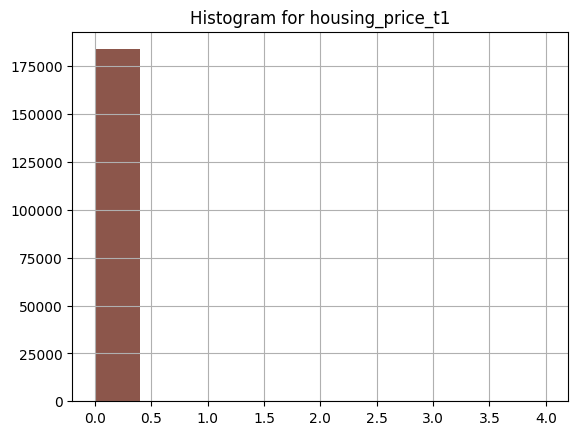

In [5]:
import matplotlib.pyplot as plt
for column in cols:
    df["annual_inc_disc"].hist()
    plt.title(f'Histogram for {column}')

In [24]:
cols = [
    "loan_amnt_disc",
    "int_rate_disc",
    "installment_disc",
    "pub_rec_disc",
    "revol_bal_disc",
    "revol_util_disc",
    "total_acc_disc",
    "annual_inc_disc",
    "delinq_2yrs_disc",
    "inq_last_6mths_disc",
    "open_acc_disc",
    "gdp_growth_t1_disc",
    "unemployment_rate_t1_disc",
    "fedfunds_t1_disc",
    "inflation_t1_disc",
    "housing_price_t1_disc",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "purpose",
    "fico_bucket_pct",
    "default_indicator",
    "age_group",
    "issue_quarter",
]

In [25]:
df = df[cols]

In [ ]:
df.to_csv('rebalanced_age_data_discretized.csv', index=False)

In [ ]:
# Structure learning
model = bn.structure_learning.fit(df, methdtype='hc')

# Compute edge strength
model = bn.independence_test(model, df)

# Make plot and put the -log10(pvalues) on the edges
bn.plot(model, edge_labels='pvalue')

dotgraph = bn.plot_graphviz(model, edge_labels='pvalue')
dotgraph

NameError: name 'bn' is not defined

In [45]:
df = bn.import_example()
model = bn.structure_learning.fit(df)
G = bn.plot(model)

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]


AttributeError: module 'pgmpy.estimators' has no attribute 'BicScore'

In [ ]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator

# Define the columns (features) as provided
cols = [
    "loan_amnt_disc",
    "int_rate_disc",
    "installment_disc",
    "pub_rec_disc",
    "revol_bal_disc",
    "revol_util_disc",
    "total_acc_disc",
    "annual_inc_disc",
    "delinq_2yrs_disc",
    "inq_last_6mths_disc",
    "open_acc_disc",
    "gdp_growth_t1_disc",
    "unemployment_rate_t1_disc",
    "fedfunds_t1_disc",
    "inflation_t1_disc",
    "housing_price_t1_disc",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "purpose",
    "fico_bucket_pct",
    "default_indicator",
    "age_group",
    "issue_quarter",
]

# Load your pre-discretized data
data = pd.read_csv('rebalanced_age_data_discretized.csv')

# Filter the data to include only the relevant columns
data = data[cols]

# Define a plausible structure for predicting default.
# Most features have a direct influence on "default_indicator".
# An example structure: loan characteristics, borrower factors, and macroeconomic factors all point to default.
# Additionally, "grade" is assumed to influence "sub_grade", and sub_grade influences default.
edges = [
    # Loan characteristics
    ("loan_amnt_disc", "default_indicator"),
    ("int_rate_disc", "default_indicator"),
    ("installment_disc", "default_indicator"),
    ("pub_rec_disc", "default_indicator"),
    ("revol_bal_disc", "default_indicator"),
    ("revol_util_disc", "default_indicator"),
    ("total_acc_disc", "default_indicator"),
    ("annual_inc_disc", "default_indicator"),
    ("delinq_2yrs_disc", "default_indicator"),
    ("inq_last_6mths_disc", "default_indicator"),
    ("open_acc_disc", "default_indicator"),
    
    # Borrower factors
    ("grade", "sub_grade"),
    ("sub_grade", "default_indicator"),
    ("emp_length", "default_indicator"),
    ("home_ownership", "default_indicator"),
    ("purpose", "default_indicator"),
    ("fico_bucket_pct", "default_indicator"),
    ("age_group", "default_indicator"),
    ("issue_quarter", "default_indicator"),
    
    # Macroeconomic conditions
    ("gdp_growth_t1_disc", "default_indicator"),
    ("unemployment_rate_t1_disc", "default_indicator"),
    ("fedfunds_t1_disc", "default_indicator"),
    ("inflation_t1_disc", "default_indicator"),
    ("housing_price_t1_disc", "default_indicator"),
]

# Initialize the Bayesian network with the assumed structure.
model = DiscreteBayesianNetwork(edges)

# Fit the parameters for the network using Bayesian estimation.
# The BayesianEstimator can be tuned with different priors if desired.
model.fit(data, estimator=BayesianEstimator, prior_type='BDeu')

# Optionally, inspect the conditional probability distributions (CPDs) to validate the learned parameters.
print("Learned CPDs:")
for cpd in model.get_cpds():
    print(cpd)

ImportError: cannot import name 'logger' from 'pgmpy.global_vars' (/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pgmpy/global_vars.py)

In [2]:
import pandas as pd
df = pd.read_csv('rebalanced_age_data_discretized.csv')

unique_subgrade_count = df['purpose'].nunique()
print("Number of unique values in sub_grade:", unique_subgrade_count)

Number of unique values in sub_grade: 14
